# Model Training Notebook

This notebook trains multiple regression models for **Price prediction** where the target is **already log-transformed**.

What this notebook does:
- Loads engineered features
- Selects a log-transformed price target column
- Trains multiple models aligned with `price_model_trainer.py`
- Compares model metrics
- Plots actual vs predicted (log price) for each model
- Highlights the best model by test RMSE

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
# Update this if you want a different file.
DATA_PATH = Path("../data/processed/main/feature_engineered.csv")

# Target is already log-scaled.
TARGET_COL = "ttm_avg_rate"

# Leakage Column
LEAK_COL = "ttm_revenue"

df = pd.read_csv(DATA_PATH)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in data.")

print(f"Data shape: {df.shape}")
print(f"Target column: {TARGET_COL}")

# Drop rows where target is missing.
df = df.dropna(subset=[TARGET_COL]).copy()

drop_cols = [TARGET_COL]
if LEAK_COL in df.columns:
    drop_cols.append(LEAK_COL)

X = df.drop(columns=drop_cols)
y = df[TARGET_COL]

# Keep only numeric features for this model set.
X = X.select_dtypes(include=[np.number, "bool"]).astype(float)

zone_cols = ['geographic_zone_Asia Pacific', 'geographic_zone_Europe', 'geographic_zone_Northern America', 'geographic_zone_Africa', 'geographic_zone_Latin America', 'geographic_zone_Middle East']
df['zone'] = df[zone_cols].idxmax(axis=1)


print(f"Feature matrix: {X.shape}")
print(f"Target stats -> min: {y.min():.4f}, max: {y.max():.4f}, mean: {y.mean():.4f}")

Data shape: (37293, 62)
Target column: ttm_avg_rate
Feature matrix: (37293, 60)
Target stats -> min: 2.2618, max: 8.1679, mean: 4.5069


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37293 entries, 0 to 37292
Data columns (total 63 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   photos_count                      37293 non-null  float64
 1   superhost                         37293 non-null  int64  
 2   latitude                          37293 non-null  float64
 3   longitude                         37293 non-null  float64
 4   guests                            37293 non-null  float64
 5   bedrooms                          37293 non-null  float64
 6   beds                              37293 non-null  float64
 7   baths                             37293 non-null  float64
 8   registration                      37293 non-null  int64  
 9   professional_management           37293 non-null  int64  
 10  min_nights                        37293 non-null  float64
 11  cancellation_policy               37293 non-null  int64  
 12  cleaning_fee   

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=df['zone'],
    random_state=42,
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (29834, 60), Test shape: (7459, 60)


In [5]:
# Main Model Training Pipeline

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42)),
    ]),
    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.0005, max_iter=10000, random_state=42)),
    ]),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=12,
        min_samples_leaf=10,
        random_state=42,
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=180,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42,
    ),
    "KNN Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=15, weights="distance", n_jobs=-1)),
    ]),
    "Support Vector Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVR(C=1.0, epsilon=0.1, max_iter=10000, random_state=42)),
    ]),
    "Neural Network Regressor": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.0001,
                batch_size=256,
                learning_rate_init=0.001,
                max_iter=200,
                early_stopping=True,
                n_iter_no_change=15,
                random_state=42,
            ),
        ),
    ]),
}

if HAS_XGBOOST:
    models["XGBoost Regressor"] = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

stacking_estimators = [
    (
        "ridge",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0, random_state=42)),
        ]),
    ),
    (
        "rf",
        RandomForestRegressor(
            n_estimators=120,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=1,
            random_state=42,
        ),
    ),
]

if HAS_XGBOOST:
    stacking_estimators.append(
        (
            "xgb",
            XGBRegressor(
                n_estimators=120,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=1,
            ),
        )
    )

models["Stacking Ensemble"] = StackingRegressor(
    estimators=stacking_estimators,
    final_estimator=Ridge(alpha=1.0, random_state=42),
    passthrough=False,
    n_jobs=-1,
)

results = []
predictions = {}
trained_models = {}

for model_name, estimator in models.items():
    estimator.fit(X_train, y_train)

    train_pred = estimator.predict(X_train)
    test_pred = estimator.predict(X_test)

    results.append(
        {
            "model": model_name,
            "train_r2": r2_score(y_train, train_pred),
            "test_r2": r2_score(y_test, test_pred),
            "train_rmse": np.sqrt(mean_squared_error(y_train, train_pred)),
            "test_rmse": np.sqrt(mean_squared_error(y_test, test_pred)),
            "train_mae": mean_absolute_error(y_train, train_pred),
            "test_mae": mean_absolute_error(y_test, test_pred),
        }
    )

    predictions[model_name] = test_pred
    trained_models[model_name] = estimator

results_df = pd.DataFrame(results).sort_values("test_rmse").reset_index(drop=True)
results_df

c:\Users\RUSHIKESH\Desktop\Airbnb Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,model,train_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae
0,Stacking Ensemble,0.9356,0.8153,0.2071,0.3439,0.1524,0.2570
1,Random Forest Regressor,0.9628,0.8121,0.1572,0.3469,0.1094,0.2564
2,XGBoost Regressor,0.8503,0.8114,0.3156,0.3475,0.2412,0.2636
3,Neural Network Regressor,0.8021,0.7370,0.3628,0.4104,0.2780,0.3163
4,KNN Regressor,1.0000,0.7036,0.0000,0.4357,0.0000,0.3287
5,Decision Tree Regressor,0.8008,0.6950,0.3640,0.4420,0.2762,0.3343
6,Lasso Regression,0.6337,0.6242,0.4937,0.4906,0.3845,0.3837
7,Ridge Regression,0.6337,0.6241,0.4937,0.4907,0.3845,0.3838
8,Linear Regression,0.6337,0.6241,0.4937,0.4907,0.3845,0.3838
9,Support Vector Regressor,0.6317,0.6220,0.4950,0.4920,0.3832,0.3829


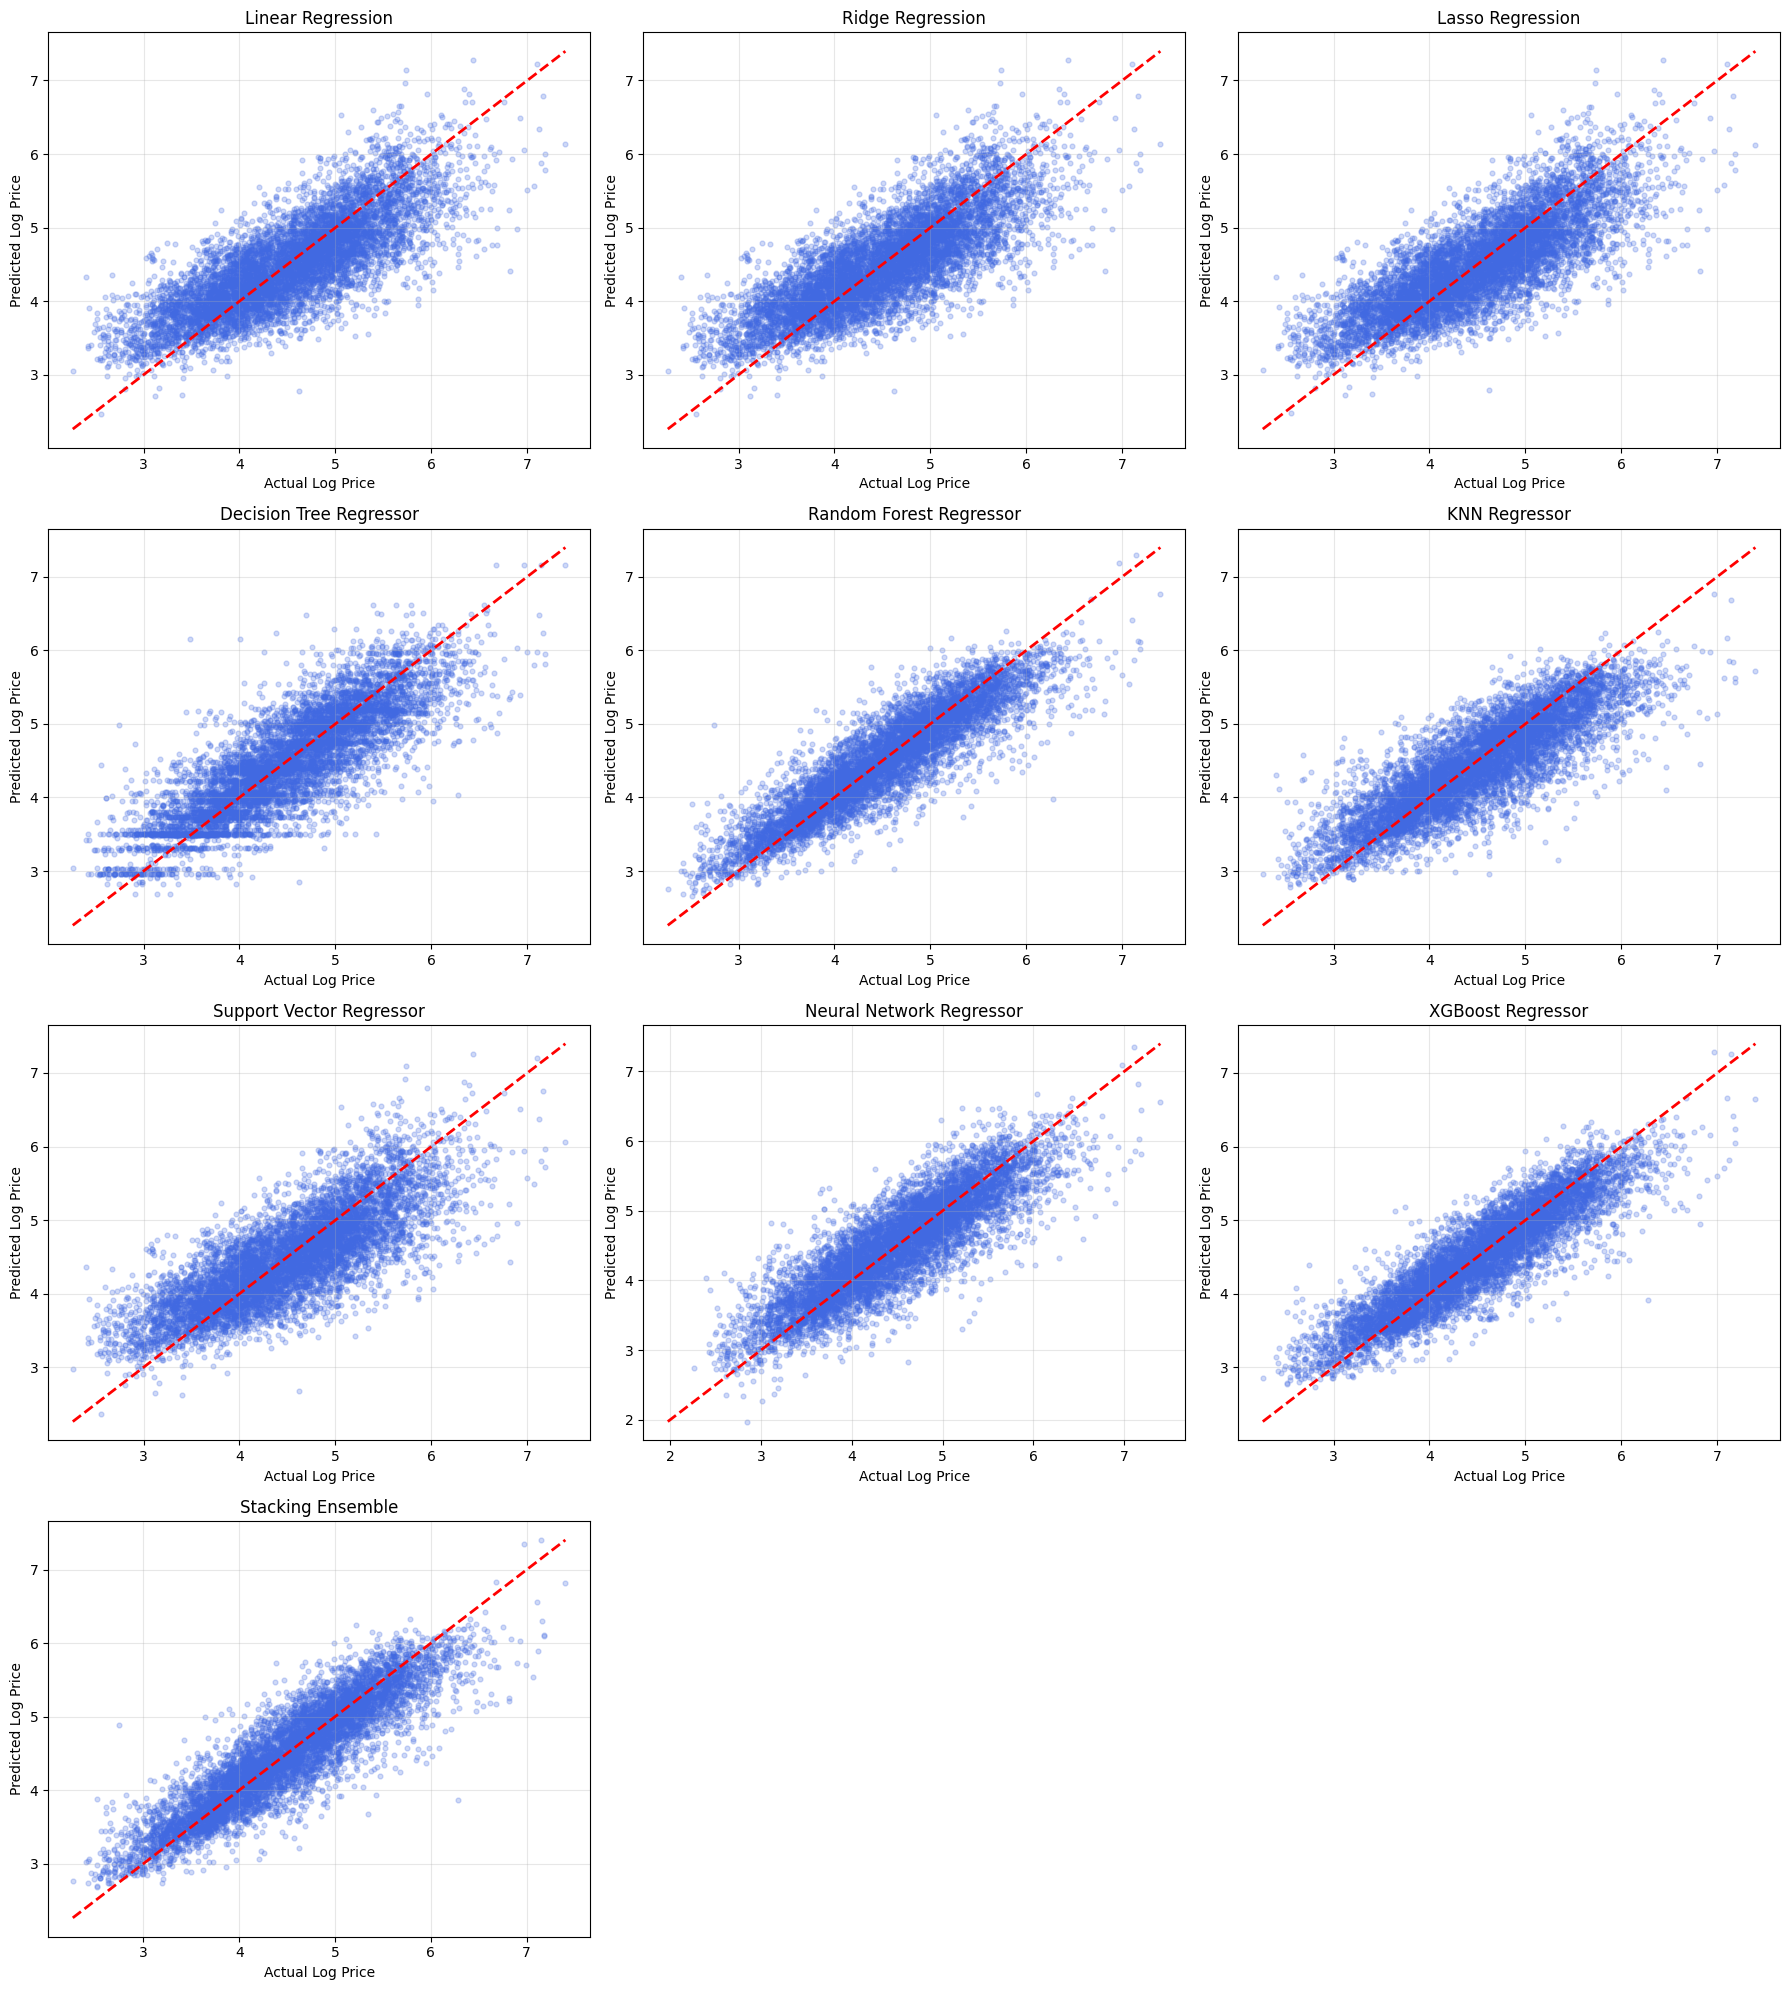

In [6]:
n_models = len(predictions)
cols = 3
rows = int(np.ceil(n_models / cols))

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.atleast_1d(axes).flatten()

y_test_arr = np.asarray(y_test)

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    y_pred_arr = np.asarray(y_pred)

    min_val = float(min(y_test_arr.min(), y_pred_arr.min()))
    max_val = float(max(y_test_arr.max(), y_pred_arr.max()))

    ax.scatter(y_test_arr, y_pred_arr, alpha=0.25, s=12, color="royalblue")
    ax.plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
    ax.set_title(model_name)
    ax.set_xlabel("Actual Log Price")
    ax.set_ylabel("Predicted Log Price")
    ax.grid(alpha=0.3)

for idx in range(n_models, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [7]:
baseline_metrics_df = results_df.copy()
baseline_metrics_df["source"] = "baseline"

hp_results = globals().get("hp_search_results", [])
hp_models = globals().get("hp_search_models", {})

metrics_frames = [baseline_metrics_df]
if len(hp_results) > 0:
    tuned_metrics_df = pd.DataFrame([result.__dict__ for result in hp_results])
    tuned_metrics_df["source"] = "tuned"
    metrics_frames.append(tuned_metrics_df)

all_model_metrics_df = pd.concat(metrics_frames, ignore_index=True)
all_model_metrics_df["overfit_gap"] = (all_model_metrics_df["train_r2"] - all_model_metrics_df["test_r2"]).abs()

eligible_models_df = all_model_metrics_df[all_model_metrics_df["test_r2"] >= 0.75].copy()
if eligible_models_df.empty:
    print("No model met test_r2 >= 0.75, falling back to all models.")
    eligible_models_df = all_model_metrics_df.copy()

eligible_models_df = eligible_models_df.sort_values(
    ["test_rmse", "test_mae", "overfit_gap", "test_r2"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

best_row = eligible_models_df.iloc[0]
best_model_name = best_row["model"]

# Resolve best model object from whichever pool it belongs to
if best_model_name in trained_models:
    best_model = trained_models[best_model_name]
elif best_model_name in hp_models:
    best_model = hp_models[best_model_name]
else:
    raise KeyError(f"Could not find fitted model object for: {best_model_name}")

print("Best model selection: ")
print(f"- Selected model: {best_model_name}")
print(f"- Source: {best_row['source']}")
print(f"- Test RMSE: {best_row['test_rmse']:.4f}")
print(f"- Test MAE: {best_row['test_mae']:.4f}")
print(f"- Test R2: {best_row['test_r2']:.4f}")
print(f"- Train R2: {best_row['train_r2']:.4f}")
print(f"- Overfit gap: {best_row['overfit_gap']:.4f}")

all_model_metrics_df.sort_values(["test_rmse", "test_mae"]).reset_index(drop=True)

Best model selection: 
- Selected model: Stacking Ensemble
- Source: baseline
- Test RMSE: 0.3439
- Test MAE: 0.2570
- Test R2: 0.8153
- Train R2: 0.9356
- Overfit gap: 0.1203


,model,train_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,source,overfit_gap
0,Stacking Ensemble,0.9356,0.8153,0.2071,0.3439,0.1524,0.2570,baseline,0.1203
1,Random Forest Regressor,0.9628,0.8121,0.1572,0.3469,0.1094,0.2564,baseline,0.1507
2,XGBoost Regressor,0.8503,0.8114,0.3156,0.3475,0.2412,0.2636,baseline,0.0388
3,Neural Network Regressor,0.8021,0.7370,0.3628,0.4104,0.2780,0.3163,baseline,0.0651
4,KNN Regressor,1.0000,0.7036,0.0000,0.4357,0.0000,0.3287,baseline,0.2964
5,Decision Tree Regressor,0.8008,0.6950,0.3640,0.4420,0.2762,0.3343,baseline,0.1059
6,Lasso Regression,0.6337,0.6242,0.4937,0.4906,0.3845,0.3837,baseline,0.0094
7,Ridge Regression,0.6337,0.6241,0.4937,0.4907,0.3845,0.3838,baseline,0.0096
8,Linear Regression,0.6337,0.6241,0.4937,0.4907,0.3845,0.3838,baseline,0.0096
9,Support Vector Regressor,0.6317,0.6220,0.4950,0.4920,0.3832,0.3829,baseline,0.0097


In [9]:
import joblib
from pathlib import Path
import json

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

model_save_path = models_dir / "best_ttm_avg_rate_model.pkl"
joblib.dump(best_model, model_save_path)
print(f"Saved selected best model ({best_model_name}) to: {model_save_path}")

feature_list_path = models_dir / "best_ttm_avg_rate_features.txt"
with open(feature_list_path, "w") as f:
    f.write("# Features used for selected TTM Average Rate model\n")
    f.write(f"# Model: {best_model_name}\n")
    f.write("# Selection criteria: test_r2 >= 0.75, then low RMSE/MAE, then low overfit gap\n")
    f.write(f"# Test RMSE: {best_row['test_rmse']:.4f}\n")
    f.write(f"# Test MAE: {best_row['test_mae']:.4f}\n")
    f.write(f"# Test R2: {best_row['test_r2']:.4f}\n")
    f.write(f"# Train R2: {best_row['train_r2']:.4f}\n")
    f.write(f"# Overfit Gap: {best_row['overfit_gap']:.4f}\n\n")
    for i, col in enumerate(X.columns, 1):
        f.write(f"{i}. {col}\n")
print(f"Saved feature list to: {feature_list_path}")

metrics_csv_path = models_dir / "all_price_model_metrics.csv"
metrics_json_path = models_dir / "all_price_model_metrics.json"

metrics_to_save = all_model_metrics_df.sort_values(
    ["test_rmse", "test_mae", "overfit_gap", "test_r2"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

metrics_to_save.to_csv(metrics_csv_path, index=False)
metrics_to_save.to_json(metrics_json_path, orient="records", indent=2)
print(f"Saved all model metrics CSV to: {metrics_csv_path}")
print(f"Saved all model metrics JSON to: {metrics_json_path}")

registry_path = models_dir / "model_registry.json"
registry = {}
if registry_path.exists():
    with open(registry_path, "r") as f:
        registry = json.load(f)

if "models" not in registry:
    registry["models"] = {}

registry["models"]["best_ttm_avg_rate"] = {
    "model_file": model_save_path.name,
    "features_file": feature_list_path.name,
    "metrics_files": {
        "all_models_csv": metrics_csv_path.name,   # fixed: was hardcoded wrong name
        "all_models_json": metrics_json_path.name, # fixed: was hardcoded wrong name
    },
    "selection_criteria": {
        "min_test_r2": 0.75,
        "priority_order": ["test_rmse", "test_mae", "overfit_gap"],
    },
    "metrics": {
        "test_rmse": float(best_row["test_rmse"]),
        "test_mae": float(best_row["test_mae"]),
        "test_r2": float(best_row["test_r2"]),
        "train_r2": float(best_row["train_r2"]),
        "train_rmse": float(best_row["train_rmse"]),
        "train_mae": float(best_row["train_mae"]),
        "overfit_gap": float(best_row["overfit_gap"]),
        "target_transform": "log1p",
        "target_column": TARGET_COL,
    },
    "model_name": best_model_name,
    "source": str(best_row["source"]),
    "feature_count": len(X.columns),
    "training_date": pd.Timestamp.now().isoformat(),
}

with open(registry_path, "w") as f:
    json.dump(registry, f, indent=2)
print(f"Updated model registry at: {registry_path}")

print("\n" + "=" * 70)
print("MODEL EXPORT SUMMARY — PRICE")
print("=" * 70)
print(f"Selected Model: {best_model_name}")
print(f"Source: {best_row['source']}")
print(f"Test RMSE: {best_row['test_rmse']:.4f}")
print(f"Test MAE:  {best_row['test_mae']:.4f}")
print(f"Test R2:   {best_row['test_r2']:.4f}")
print(f"Overfit Gap: {best_row['overfit_gap']:.4f}")
print(f"Model Path: {model_save_path}")
print(f"Metrics CSV: {metrics_csv_path}")
print(f"Metrics JSON: {metrics_json_path}")
print("=" * 70)

Saved selected best model (Stacking Ensemble) to: ..\models\best_ttm_avg_rate_model.pkl
Saved feature list to: ..\models\best_ttm_avg_rate_features.txt
Saved all model metrics CSV to: ..\models\all_price_model_metrics.csv
Saved all model metrics JSON to: ..\models\all_price_model_metrics.json
Updated model registry at: ..\models\model_registry.json

MODEL EXPORT SUMMARY — PRICE
Selected Model: Stacking Ensemble
Source: baseline
Test RMSE: 0.3439
Test MAE:  0.2570
Test R2:   0.8153
Overfit Gap: 0.1203
Model Path: ..\models\best_ttm_avg_rate_model.pkl
Metrics CSV: ..\models\all_price_model_metrics.csv
Metrics JSON: ..\models\all_price_model_metrics.json
